# Chpater 10. 머신 러닝 애플리케이션을 위한 양자 커널 훈련(Quantum Kernel Training)

이 튜토리얼에서는 머신 러닝 애플리케이션을 위해 레이블이 지정된 데이터세트에 양자 커널을 훈련한다. 기본 단계를 설명하기 위해 이진 분류 작업에 양자 커널 정렬(QKA, Quantum Kernel Alignment)을 사용한다. QKA는 데이터세트에 매개변수화된 양자 커널을 반복적으로 적응시켜 최대 SVM 마진에 수렴하는 기법이다. QKA에 대한 자세한 정보는 사전 인쇄본 "Covariant quantum kernels for data with group structure"에서 찾을 수 있다.

양자 커널 훈련의 진입점은 `QuantumKernelTrainer` 클래스이다. 기본 단계는 다음과 같다:

1. 데이터세트 준비한다
2. 양자 특성 맵을 정의한다
3. `TrainableKernel` 및 `QuantumKernelTrainer` 객체의 인스턴스를 설정한다
4. `QuantumKernelTrainer.fit` 메서드를 사용하여 데이터세트에 대해 커널 매개변수를 훈련한다
5. 훈련된 양자 커널을 머신 러닝 모델에 전달한다

### 로컬, 외부 및 Qiskit 패키지를 가져오고 옵티마이저용 콜백 클래스를 정의한다

In [1]:
# 외부 라이브러리와 Qiskit 패키지를 가져온다
# External imports
from pylab import cm
from sklearn import metrics
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.visualization import circuit_drawer
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.optimizers import SPSA
from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.datasets import ad_hoc_data

In [2]:
class QKTCallback:
    """Callback wrapper class."""

    def __init__(self) -> None:
        self._data = [[] for i in range(5)]

    def callback(self, x0, x1=None, x2=None, x3=None, x4=None):
        """
        Args:
            x0: number of function evaluations
            x1: the parameters
            x2: the function value
            x3: the stepsize
            x4: whether the step was accepted
        """
        self._data[0].append(x0)
        self._data[1].append(x1)
        self._data[2].append(x2)
        self._data[3].append(x3)
        self._data[4].append(x4)

    def get_callback_data(self):
        return self._data

    def clear_callback_data(self):
        self._data = [[] for i in range(5)]

### 데이터세트 준비한다

이 가이드에서는 Qiskit 머신 러닝의 `ad_hoc.py` 데이터세트를 사용하여 커널 훈련 프로세스를 시연한다. 문서는 [여기](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.datasets.ad_hoc_data.html)를 참조한다.

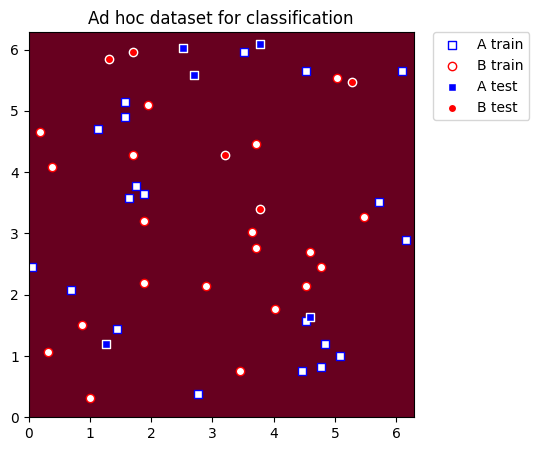

In [3]:
# ad_hoc 데이터세트를 로드한다
adhoc_dimension = 2
X_train, y_train, X_test, y_test, adhoc_total = ad_hoc_data(
    training_size=20,
    test_size=5,
    n=adhoc_dimension,
    gap=0.3,
    plot_data=False,
    one_hot=False,
    include_sample_total=True,
)

plt.figure(figsize=(5, 5))
plt.ylim(0, 2 * np.pi)
plt.xlim(0, 2 * np.pi)
plt.imshow(
    np.asmatrix(adhoc_total).T,
    interpolation="nearest",
    origin="lower",
    cmap="RdBu",
    extent=[0, 2 * np.pi, 0, 2 * np.pi],
)

plt.scatter(
    X_train[np.where(y_train[:] == 0), 0],
    X_train[np.where(y_train[:] == 0), 1],
    marker="s",
    facecolors="w",
    edgecolors="b",
    label="A train",
)
plt.scatter(
    X_train[np.where(y_train[:] == 1), 0],
    X_train[np.where(y_train[:] == 1), 1],
    marker="o",
    facecolors="w",
    edgecolors="r",
    label="B train",
)
plt.scatter(
    X_test[np.where(y_test[:] == 0), 0],
    X_test[np.where(y_test[:] == 0), 1],
    marker="s",
    facecolors="b",
    edgecolors="w",
    label="A test",
)
plt.scatter(
    X_test[np.where(y_test[:] == 1), 0],
    X_test[np.where(y_test[:] == 1), 1],
    marker="o",
    facecolors="r",
    edgecolors="w",
    label="B test",
)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.title("Ad hoc dataset for classification")

plt.show()

### 양자 특성 맵을 정의한다

다음으로 고전 데이터를 양자 상태 공간으로 인코딩하는 양자 특성 맵을 설정한다. 여기서 `QuantumCircuit`를 사용하여 훈련 가능한 회전 층을 설정하고 `Qiskit`의 `zz_feature_map`을 사용하여 입력 데이터를 표현한다.

Trainable parameters: θ, ['θ[0]']


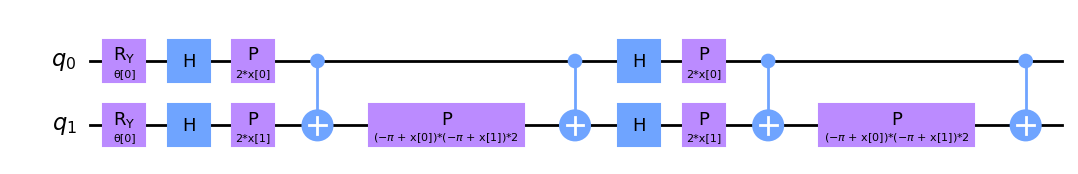

In [4]:
# 회전 층을 생성하고 입력 데이터를 표현하기 위해 ZZFeatureMap을 사용한다
# Create a rotational layer to train. We will rotate each qubit the same amount.
training_params = ParameterVector("θ", 1)
fm0 = QuantumCircuit(2)
fm0.ry(training_params[0], 0)
fm0.ry(training_params[0], 1)

# Use ZZFeatureMap to represent input data
fm1 = zz_feature_map(2)

# Create the feature map, composed of our two circuits
fm = fm0.compose(fm1)

print(f"Trainable parameters: {training_params}")
fm.draw(output="mpl", style="clifford")

### 양자 커널과 양자 커널 훈련기를 설정한다

양자 커널을 훈련하기 위해 `TrainableFidelityQuantumKernel`의 인스턴스(특성 맵과 매개변수를 보유함)와 `QuantumKernelTrainer`(훈련 프로세스를 관리함)를 사용한다.

Quantum Kernel Alignment 기법을 사용하여 훈련하며, 커널 손실 함수 `SVCLoss`를 `QuantumKernelTrainer`에 대한 입력으로 선택한다. 이것은 Qiskit 지원 손실이므로 문자열 `"svc_loss"`를 사용할 수 있다. 그러나 손실을 문자열로 전달할 때 기본 설정이 사용됨에 유의한다. 사용자 정의 설정의 경우 원하는 옵션으로 명시적으로 인스턴스화하고 `KernelLoss` 객체를 `QuantumKernelTrainer`에 전달한다.

옵티마이저로 SPSA를 선택하고 `initial_point` 인수로 훈련 가능한 매개변수를 초기화한다. 참고: `initial_point` 인수로 전달되는 리스트의 길이는 특성 맵의 훈련 가능한 매개변수 수와 같아야 한다.

In [5]:
# ComputeUncompute 신뢰도와 StatevectorSampler를 사용하여 양자 커널을 인스턴스화한다
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)

# Instantiate quantum kernel
quant_kernel = TrainableFidelityQuantumKernel(
    fidelity=fidelity, feature_map=fm, training_parameters=training_params
)

# Set up the optimizer
cb_qkt = QKTCallback()
spsa_opt = SPSA(maxiter=10, callback=cb_qkt.callback, learning_rate=0.05, perturbation=0.05)

# Instantiate a quantum kernel trainer.
qkt = QuantumKernelTrainer(
    quantum_kernel=quant_kernel, loss="svc_loss", optimizer=spsa_opt, initial_point=[np.pi / 2]
)

### 양자 커널을 훈련한다

데이터세트(샘플 및 레이블)에서 양자 커널을 훈련하기 위해 `QuantumKernelTrainer`의 `fit` 메서드를 호출한다.

`QuantumKernelTrainer.fit`의 출력은 `QuantumKernelTrainerResult` 객체이다. 결과 객체는 다음 클래스 필드를 포함한다:

 - `optimal_parameters`: {매개변수: 최적값} 쌍을 포함하는 딕셔너리
 - `optimal_point`: 훈련에서 �은 최적 매개변수 값
 - `optimal_value`: 최적 지점에서의 손실 함수 값
 - `optimizer_evals`: 옵티마이저가 수행한 평가 수
 - `optimizer_time`: 최적화를 수행하는 데 소요된 시간
 - `quantum_kernel`: 특성 맵에 최적값이 바인딩된 `TrainableKernel` 객체

In [6]:
# QuantumKernelTrainer를 사용하여 커널을 훈련한다
# Train the kernel using QKT directly
qka_results = qkt.fit(X_train, y_train)
optimized_kernel = qka_results.quantum_kernel
print(qka_results)

{   'optimal_circuit': None,
    'optimal_parameters': {   ParameterVectorElement(θ[0]): np.float64(-0.15321950243910099)},
    'optimal_point': array([-0.1532195]),
    'optimal_value': np.float64(8.196079681257025),
    'optimizer_evals': 30,
    'optimizer_result': None,
    'optimizer_time': None,
    'quantum_kernel': <qiskit_machine_learning.kernels.trainable_fidelity_quantum_kernel.TrainableFidelityQuantumKernel object at 0x125d356c0>}


### 모델을 피팅하고 테스트한다

훈련된 양자 커널을 머신 러닝 모델에 전달한 다음 모델을 피팅하고 새로운 데이터에서 테스트할 수 있다. 여기서는 Qiskit 머신 러닝의 `QSVC`를 분류에 사용한다.

In [7]:
# QSVC로 분류를 수행한다
# Use QSVC for classification
qsvc = QSVC(quantum_kernel=optimized_kernel)

# Fit the QSVC
qsvc.fit(X_train, y_train)

# Predict the labels
labels_test = qsvc.predict(X_test)

# Evalaute the test accuracy
accuracy_test = metrics.balanced_accuracy_score(y_true=y_test, y_pred=labels_test)
print(f"accuracy test: {accuracy_test}")

accuracy test: 1.0


### 커널 훈련 프로세스를 시각화한다

콜백 데이터에서 훈련 프로세스 중에 손실이 어떻게 변하는지 플롯할 수 있다. 입력 선택에 따라 이 데이터세트에서 빠르게 수렴하고 높은 테스트 정확도에 도달함을 알 수 있다.

또한 훈련 샘플 간의 유사성을 측정하는 최종 커널 행렬을 표시할 수 있다.

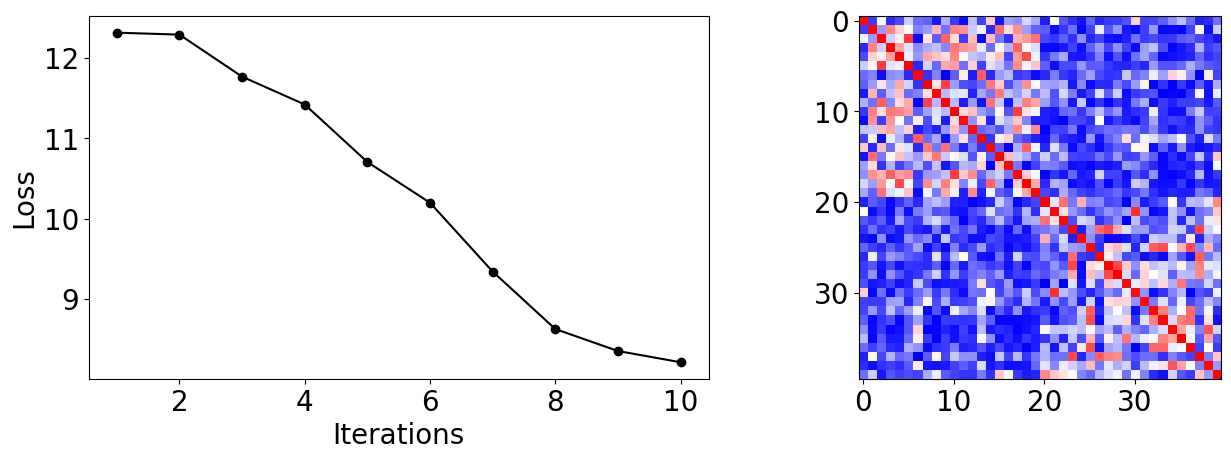

In [8]:
# 콜백 데이터로부터 손실의 진화를 플롯하고 최종 커널 행렬을 표시한다
plot_data = cb_qkt.get_callback_data()  # callback data
K = optimized_kernel.evaluate(X_train)  # kernel matrix evaluated on the training samples

plt.rcParams["font.size"] = 20
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot([i + 1 for i in range(len(plot_data[0]))], np.array(plot_data[2]), c="k", marker="o")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("Loss")
ax[1].imshow(K, cmap=matplotlib.colormaps["bwr"])
fig.tight_layout()
plt.show()

In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright